In [1]:
import warnings
warnings.filterwarnings(action='ignore', module='pandas')
warnings.filterwarnings(action='ignore', category=FutureWarning, module='ipykernel')
warnings.filterwarnings(action='ignore', category=FutureWarning, module='scanpy')
warnings.filterwarnings(action='ignore', category=FutureWarning, module='anndata')
warnings.filterwarnings(action='ignore', category=UserWarning, module='scanpy')

In [2]:
import os
from tqdm import tqdm

import scanpy as sc
import anndata as ad
from kneed import KneeLocator

import h5py
from scipy.sparse import csc_matrix
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import omnipath as op

import seaborn as sns
import matplotlib.pyplot as plt

import sys
sclembas_path = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas_path))
from scLEMBAS import preprocess as pp
from scLEMBAS import io

/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
seed = 888
author = 'Kang'

n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(1)
os.environ["MKL_NUM_THREADS"] = str(1)
os.environ["OPENBLAS_NUM_THREADS"] = str(1)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(1)
os.environ["NUMEXPR_NUM_THREADS"] = str(1)

Load the files:

In [4]:
h5_file = os.path.join(data_path, 'raw', 'kang_2017_raw_counts.h5')
with h5py.File(h5_file, "r") as f:
    data = f["data"][:]
    indices = f["i"][:]
    indptr = f["p"][:]
    dims = f["dims"][:]
    
    row_names = list(f["rownames"][:].astype(str))
    col_names = list(f["colnames"][:].astype(str))

sparse_matrix = csc_matrix((data, indices, indptr), shape=(dims[0], dims[1]))
expr = pd.DataFrame.sparse.from_spmatrix(sparse_matrix, index=row_names, columns=col_names)
md = pd.read_csv(os.path.join(data_path, 'raw', 'kan_2017_md.csv'), index_col = 0)
adata = sc.AnnData(X = expr.T, obs = md)

QC:

In [5]:
# adata.var["mt"] = adata.var_names.str.startswith("MT-")
# sc.pp.calculate_qc_metrics(
#     adata, qc_vars=["mt"], inplace=True, log1p=True
# )


# sc.pl.violin(
#     adata,
#     ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
#     jitter=0.4,
#     multi_panel=True,
# )

sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

Drop rare cell types:

In [6]:
cat_col = 'seurat_annotations'
pert_col = 'stim'

In [7]:
vc = adata.obs[cat_col].value_counts(normalize = True)[::-1]
rare_cells = vc[:3].index.tolist()

print('The following cells will be dropped because they are too rare: ')
print(*rare_cells, sep = ', ')

vc*100

The following cells will be dropped because they are too rare: 
Eryth, pDC, Mk


seurat_annotations
Eryth            0.392885
pDC              0.942924
Mk               1.685835
B Activated      2.771627
DC               3.371669
NK               4.421744
T activated      4.521752
CD8 T            5.814701
B                6.986213
CD16 Mono        7.457676
CD4 Memory T    12.586613
CD4 Naive T     17.886992
CD14 Mono       31.159369
Name: proportion, dtype: float64

In [8]:
mask = ~adata.obs[cat_col].isin(rare_cells)
adata = adata[mask].copy()
    
adata.obs[cat_col].value_counts(normalize = True)*100

seurat_annotations
CD14 Mono       32.130230
CD4 Naive T     18.444313
CD4 Memory T    12.978786
CD16 Mono        7.690041
B                7.203889
CD8 T            5.995875
T activated      4.662640
NK               4.559517
DC               3.476724
B Activated      2.857985
Name: proportion, dtype: float64

In [9]:
adata.obs[pert_col] = pd.Categorical(adata.obs[pert_col], 
                                    categories = ['CTRL', 'STIM'], 
                                    ordered = True)

cats = sorted(adata.obs[cat_col].unique())
adata.obs[cat_col] = pd.Categorical(adata.obs[cat_col], categories = cats, ordered = True)

adata.obs['condition'] = adata.obs[cat_col].astype(str) + '^' + adata.obs[pert_col].astype(str)

Normalize:

In [10]:
adata.layers["counts"] = adata.X.copy() # store the raw data
sc.pp.normalize_total(adata, target_sum = 1e6)
sc.pp.log1p(adata)

Select HVGs:

In [11]:
sc.pp.highly_variable_genes(adata, n_top_genes=5000, batch_key=None, flavor = 'seurat')

A note on batch correction:
    
The original [paper](https://doi.org/10.1038/nbt.4042) pooled samples together. So there isn't batch across stimulation condition or sample. There are batches, but the paper showed gene expression is reproducible across these. Given this, batch effect correction is not necessary. While the Seurat vignette does apply batch effect correction on stimulation condition to this dataset in their vignette, this is just meant as an example of how their method can group like cell types together and wouldn't be appropriate here as it is not the batch condition. 

Get TF activity scores:

In [12]:
kwargs = {'args' : {'wsum' : {'times': int(1), # no p-vals used
                              'batch_size': int(1e4)},
                       'ulm' : {'batch_size': int(1e4)}, 
                        'mlm': {'batch_size': int(1e4)}
                       }, 
#          'methods': ['wsum', 'ulm', 'mlm'], 
         'cns_metds': ['ulm_estimate', 'mlm_estimate', 'wsum_estimate']}
# default is wsum_norm, which introduces inf values that result in nan when z-scoring..
# also intuitively doesnt make sense to z-score an already normalized value
# particularly when the other z-scores or on the non-normalized values



adata = pp.get_tf_activity(adata, organism = 'human', grn = 'collectri', verbose = True,
                consensus = True, hvg = True,
                min_n = 5, use_raw = False, filter_pvals = False, pval_thresh = 0.05, **kwargs)

adata.write_h5ad(os.path.join(data_path, 'processed', '{}_expr_scored.h5ad'.format(author)))

Running scores.
Running mlm on mat with 13576 samples and 5000 targets for 418 sources.


100%|█████████████████████████████████████████████| 2/2 [00:03<00:00,  1.60s/it]


Running ulm on mat with 13576 samples and 5000 targets for 418 sources.


100%|█████████████████████████████████████████████| 2/2 [00:00<00:00,  4.31it/s]


Running wsum on mat with 13576 samples and 5000 targets for 418 sources.


100%|█████████████████████████████████████████████| 2/2 [00:00<00:00,  8.12it/s]


''

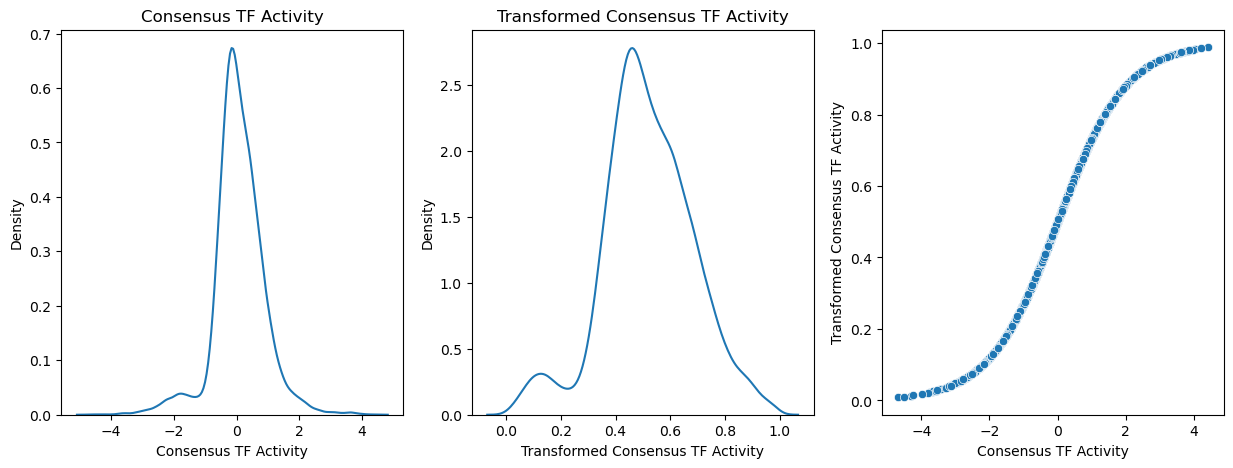

In [13]:
fig, ax = plt.subplots(ncols = 3, figsize = (15,5))

vals = adata.obsm['consensus_estimate'].values.flatten()
vals_transformed = pp.transform_tf_activity(adata.obsm['consensus_estimate']).values.flatten()
scores = pd.DataFrame(data = {'Consensus TF Activity': vals, 
                    'Transformed Consensus TF Activity': vals_transformed})
scores_subset = scores.sample(n=int(1e4), random_state=seed)


sns.kdeplot(scores_subset['Consensus TF Activity'], ax = ax[0])
ax[0].set_title('Consensus TF Activity')

sns.kdeplot(scores_subset['Transformed Consensus TF Activity'], ax = ax[1])
ax[1].set_title('Transformed Consensus TF Activity')

sns.scatterplot(data = scores_subset, x = 'Consensus TF Activity', 
                y = 'Transformed Consensus TF Activity', ax = ax[2])
;

In [14]:
# fn_csv = os.path.join(data_path, 'interim', '{}_TF_activity.csv'.format(author)) 

# # for key in adata.obsm:
# #     if key.endswith('estimate') or key.endswith('pvals'):
# #         fn_csv_ = fn_csv.replace('TF_activity', key + '_TF_activity')
# #         adata.obsm[key].to_csv(fn_csv_)

tf_adata = pp.tf_to_adata(adata, estimate_key = 'consensus_estimate')

if list(tf_adata.var_names) != sorted(tf_adata.var_names):
    tf_adata = tf_adata[:, sorted(tf_adata.var_names)].copy() 
    
io.write_tfad(tf_adata, file_name = os.path.join(data_path, 'interim', '{}_tf_activity.h5ad'.format(author)))